## Nguyen Phuc Minh Chau - Lab03

1. Sử dụng thư viện: nltk và Underthesea để thực hiện Word Tokenize cho đoạn text.

2. Vẽ biểu đồ (Phổ đồ tần số (Mel-spectrogram), cao độ (Pitch), Biểu đồ sóng âm (Waveform) cho 1 file âm thanh.

3. Sử dụng thư viện pyttsx3, gTTS để đọc 1 đoạn text

### Import Library

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
import underthesea as us

import librosa
import matplotlib.pyplot as plt
import numpy as np

import pyttsx3
from gtts import gTTS
import IPython.display as ipd
import sounddevice as sd

[nltk_data] Downloading package punkt to /home/zhu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/zhu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 1. Sử dụng thư viện: nltk và Underthesea để thực hiện Word Tokenize cho đoạn text.

In [3]:
text_en = "There is a boy whose love to play football drinking a cup of tea because he's so tire"
text_vi = "Có thằng nhóc chơi bóng đá vì quá mệt mà đá ly nước trà đá."

tokens_en = nltk.word_tokenize(text_en)

tokens_vi = us.word_tokenize(text_vi)

print("English tokens:", tokens_en)
print("Vietnamese tokens:", tokens_vi)

English tokens: ['There', 'is', 'a', 'boy', 'whose', 'love', 'to', 'play', 'football', 'drinking', 'a', 'cup', 'of', 'tea', 'because', 'he', "'s", 'so', 'tire']
Vietnamese tokens: ['Có', 'thằng', 'nhóc', 'chơi', 'bóng đá', 'vì', 'quá', 'mệt', 'mà', 'đá ly', 'nước', 'trà', 'đá', '.']


### 2. Vẽ biểu đồ (Phổ đồ tần số (Mel-spectrogram), cao độ (Pitch), Biểu đồ sóng âm (Waveform) cho 1 file âm thanh.

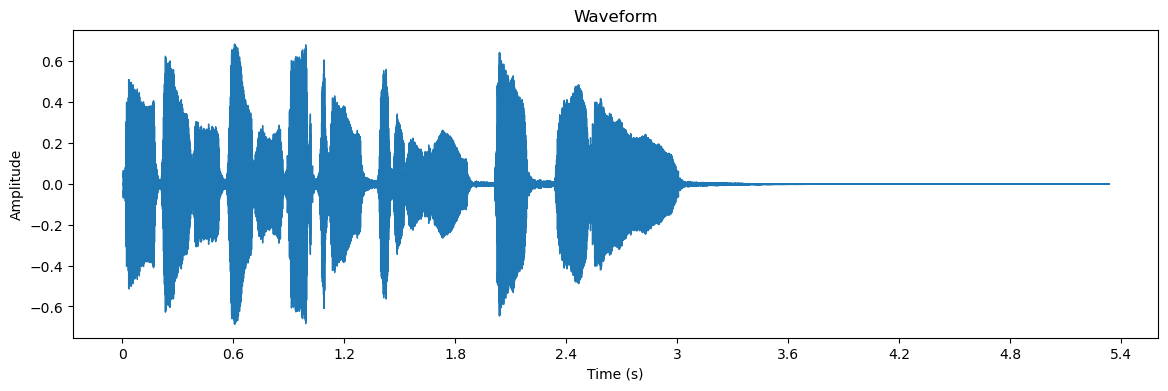

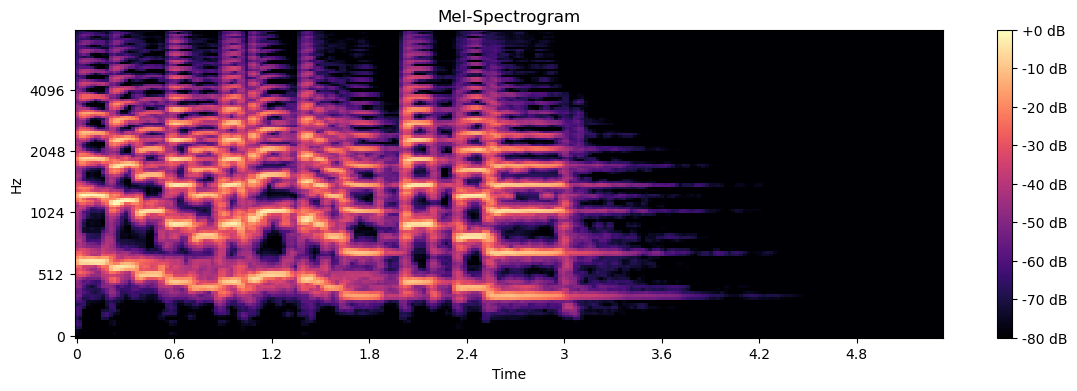

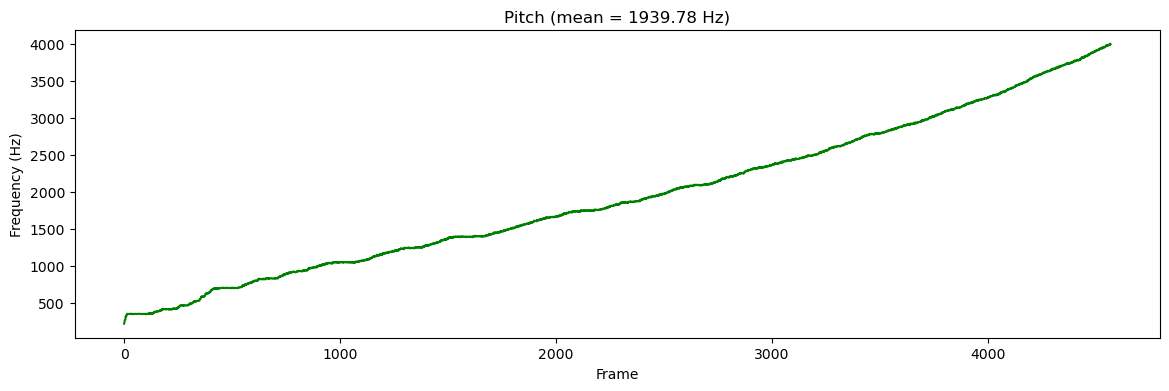

In [4]:
file_path = librosa.example('trumpet')
y, sr = librosa.load(file_path)

# Waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Mel-Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(14, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram')
plt.show()

# Pitch
pitch, mag = librosa.piptrack(y=y, sr=sr)
pitch_mean = np.mean(pitch[pitch > 0])

plt.figure(figsize=(14, 4))
plt.plot(pitch[pitch > 0], color='green')
plt.title(f'Pitch (mean = {pitch_mean:.2f} Hz)')
plt.xlabel('Frame')
plt.ylabel('Frequency (Hz)')
plt.show()

### 3. Sử dụng thư viện pyttsx3, gTTS để đọc 1 đoạn text

In [5]:
engine = pyttsx3.init()
engine.setProperty('rate', 150)
engine.setProperty('volume', 0.9)

text = "I love the Daisy Bell song but still can't singing it as all"
engine.say(text)
engine.runAndWait()

In [ ]:
text_vi = "Tôi rất thích bài hát Daisy Bell nhưng tôi chưa từng hát được bài hát đó"
tts = gTTS(text=text_vi, lang='vi')

# Phát trực tiếp trong notebook
ipd.Audio("output.mp3")